<a href="https://colab.research.google.com/github/e-voch/Mean-Reversion-Strategy/blob/main/mean_reversion_strategy_with_fees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating a Mean Reversion strategy

In this video, we are going to create a professional mean reversion strategy

Want to show how mean reversion is traded professionally as what you see on the internet is not 100% accurate.

This is a strategy that you can trade manually or automatically.

I'm a strong advocate of simplicity and this strategy is not going to use any machine-learning nor advanced mathematics.

It's just going to be using basic econometrics.

Financial data is extremely noisy yet there are statistical patterns that exhibit inside that are not visible to the naked eye.
There's a misconception that you cannot make money with basic strategies because the markets are complex - this is futher from the truth.

## Goal = Find a statistical pattern

![Alt text](https://i.postimg.cc/023pdYK0/BCH.png)

In [1]:
import numpy as np
import pandas as pd

We have Bitcoin Cash data. I know nothing about this project or coin or the history. All that I am interested in is its price movements.

In [2]:
url = "https://drive.google.com/uc?export=download&id=1eQN7nCrv1byqqX8oIt1Ks6SlDFb_ySlc"
df = pd.read_csv(url)
del df['Unnamed: 0']
df


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir
0,2022-04-13,2022-04-13 23:59:59.999,BCH,1d,304.73,340.90,349.63,301.03,0.000,0,NaN,NaN,-1,-1
1,2022-04-14,2022-04-14 23:59:59.999,BCH,1d,340.90,337.42,353.00,332.34,0.000,0,-0.010261,NaN,-1,-1
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1


## Create Log Returns

In [3]:
df['close_log_return'] = np.log(df['c']/df['c'].shift(1))
df

,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir
0,2022-04-13,2022-04-13 23:59:59.999,BCH,1d,304.73,340.90,349.63,301.03,0.000,0,NaN,NaN,-1,-1
1,2022-04-14,2022-04-14 23:59:59.999,BCH,1d,340.90,337.42,353.00,332.34,0.000,0,-0.010261,NaN,-1,-1
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1


## Create Auto-Regressive Log Returns

In [4]:
df['close_log_return_lag_1'] = df['close_log_return'].shift(1)
df = df.dropna()
df

,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1


## Encode Direction

* 1 => Long => Bet up
* -1 => Short => Bet down

In [5]:
for col in ['close_log_return','close_log_return_lag_1']:
    df[f'{col}_dir'] = df[col].map(lambda x: 1 if x > 0 else -1)
df

/tmp/ipykernel_1552/37754665.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{col}_dir'] = df[col].map(lambda x: 1 if x > 0 else -1)


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1


## Study Auto-Regressive Price Movements

In [6]:
df.groupby('close_log_return_lag_1_dir').aggregate({'close_log_return':['mean','count', 'sum']})

close_log_return                
                                       mean count       sum
close_log_return_lag_1_dir                                 
-1                                 0.002281   734  1.674421
 1                                -0.001990   725 -1.442438

## How to interpret this?

Well it exhibits strong mean reversion behaviour

1. If the previous price movement went down, it has a strong price movement that it will go up in the next day.
2. If the previous price movement went up, it has a strong price movement that it will go down in the next day.

## Out-of-Sample Validation

To determine whether the observed pattern persists over time rather than being a temporary effect, the statistic is evaluated on a holdout dataset consisting of the most recent observations.

This ensures that the results generalize beyond the in-sample period.

In [7]:
i = int(len(df) * 0.75)

in_sample, out_sample = df.iloc[:i], df.iloc[i:]

in_sample.groupby('close_log_return_lag_1_dir').aggregate({'close_log_return':['mean','count', 'sum']})

close_log_return                
                                       mean count       sum
close_log_return_lag_1_dir                                 
-1                                 0.002007   553  1.109951
 1                                -0.002014   541 -1.089592

In [8]:
out_sample.groupby('close_log_return_lag_1_dir').aggregate({'close_log_return':['mean','count', 'sum']})

close_log_return                
                                       mean count       sum
close_log_return_lag_1_dir                                 
-1                                 0.003119   181  0.564470
 1                                -0.001918   184 -0.352846

We can see the pattern persists in the out-of-sample so this means that the mean reversion behaviour persists with the most recent data.

## Display Equity Curve

We are interested to know what the equity curve looks like if we traded this mean reversion strategy.

In [9]:
df['signal'] = -1 * df['close_log_return_lag_1_dir']
df

/tmp/ipykernel_1552/2769368292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['signal'] = -1 * df['close_log_return_lag_1_dir']


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1,1
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1,-1
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1,-1
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1,1
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1,-1
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1,1
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1,-1
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1,-1


In [10]:
df['trade_log_return'] = df['signal'] * df['close_log_return']
df

/tmp/ipykernel_1552/2468843582.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trade_log_return'] = df['signal'] * df['close_log_return']


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1,1,0.009439
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1,-1,-0.005738
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1,-1,0.043949
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1,1,0.037095
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1,-1,-0.000118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1,-1,0.010372
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1,1,0.003416
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1,-1,-0.001986
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1,-1,0.014281


In [ ]:
df['cumulative_trade_log_return'] = df['trade_log_return'].cumsum()
df

/tmp/ipykernel_1552/2637444162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cumulative_trade_log_return'] = df['trade_log_return'].cumsum()


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1,1,0.009439,0.009439
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1,-1,-0.005738,0.003701
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1,-1,0.043949,0.047650
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1,1,0.037095,0.084745
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1,-1,-0.000118,0.084628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1,-1,0.010372,3.128501
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1,1,0.003416,3.131917
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1,-1,-0.001986,3.129932
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1,-1,0.014281,3.144212


<Axes: >

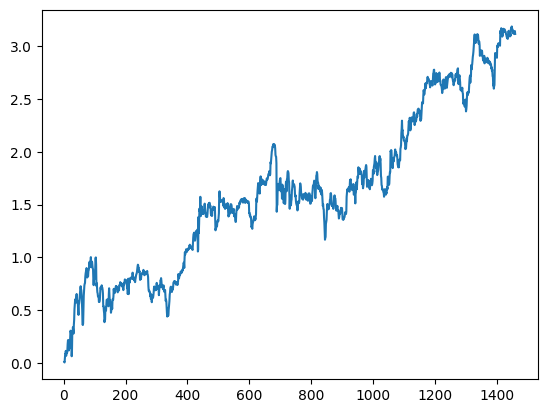

In [14]:
df['trade_log_return'].cumsum().plot()

## Strategy Statistics

Win Rate

In [23]:
df['is_won'] = df['trade_log_return'] > 0
df


/tmp/ipykernel_1552/2305063718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_won'] = df['trade_log_return'] > 0


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1,1,0.009439,0.009439,True
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1,-1,-0.005738,0.003701,False
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1,-1,0.043949,0.047650,True
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1,1,0.037095,0.084745,True
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1,-1,-0.000118,0.084628,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1,-1,0.010372,3.128501,True
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1,1,0.003416,3.131917,True
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1,-1,-0.001986,3.129932,False
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1,-1,0.014281,3.144212,True


In [24]:
df['is_won'].mean()

np.float64(0.5291295407813571)

Total Gross Compound Return

In [25]:
r = np.exp(df['trade_log_return'].sum()) - 1
r

np.float64(21.575359341230723)

In [ ]:
12 * r

np.float64(215753.59341230724)

Annualized Sharpe

In [32]:
df['trade_log_return'].mean()

np.float64(0.0021362981609587767)

In [33]:
df['trade_log_return'].std()

0.04319314755088691

In [34]:
df['trade_log_return'].mean() / df['trade_log_return'].std() * np.sqrt(365)

np.float64(0.9449165289438253)

## Add Round-Trip Fees

In [35]:
df['cum_trade_log_return'] = df['trade_log_return'].cumsum()
df

/tmp/ipykernel_1552/3441787508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cum_trade_log_return'] = df['trade_log_return'].cumsum()


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1,1,0.009439,0.009439,True,0.009439
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1,-1,-0.005738,0.003701,False,0.003701
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1,-1,0.043949,0.047650,True,0.047650
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1,1,0.037095,0.084745,True,0.084745
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1,-1,-0.000118,0.084628,False,0.084628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1,-1,0.010372,3.128501,True,3.128501
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1,1,0.003416,3.131917,True,3.131917
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1,-1,-0.001986,3.129932,False,3.129932
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1,-1,0.014281,3.144212,True,3.144212


In [36]:
capital = 1000
df['post_trade_notional_value'] = capital + df['cum_trade_log_return'] * capital
df

/tmp/ipykernel_1552/532556028.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['post_trade_notional_value'] = capital + df['cum_trade_log_return'] * capital


,t,T,s,i,o,c,h,l,v,n,close_log_return,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,0.009439,-0.010261,1,-1,1,0.009439,0.009439,True,0.009439,1009.439041
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,0.005738,0.009439,1,1,-1,-0.005738,0.003701,False,0.003701,1003.701321
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,-0.043949,0.005738,-1,1,-1,0.043949,0.047650,True,0.047650,1047.650341
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,0.037095,-0.043949,1,-1,1,0.037095,0.084745,True,0.084745,1084.745405
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,0.000118,0.037095,1,1,-1,-0.000118,0.084628,False,0.084628,1084.627848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,-0.010372,0.025075,-1,1,-1,0.010372,3.128501,True,3.128501,4128.500862
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,0.003416,-0.010372,1,-1,1,0.003416,3.131917,True,3.131917,4131.917348
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,0.001986,0.003416,1,1,-1,-0.001986,3.129932,False,3.129932,4129.931653
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,-0.014281,0.001986,-1,1,-1,0.014281,3.144212,True,3.144212,4144.212259


In [37]:
df['pre_trade_notional_value'] = df['post_trade_notional_value'].shift()
df

/tmp/ipykernel_1552/3368718721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pre_trade_notional_value'] = df['post_trade_notional_value'].shift()


,t,T,s,i,o,c,h,l,v,n,...,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,-0.010261,1,-1,1,0.009439,0.009439,True,0.009439,1009.439041,NaN
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,0.009439,1,1,-1,-0.005738,0.003701,False,0.003701,1003.701321,1009.439041
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,0.005738,-1,1,-1,0.043949,0.047650,True,0.047650,1047.650341,1003.701321
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,-0.043949,1,-1,1,0.037095,0.084745,True,0.084745,1084.745405,1047.650341
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,0.037095,1,1,-1,-0.000118,0.084628,False,0.084628,1084.627848,1084.745405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,0.025075,-1,1,-1,0.010372,3.128501,True,3.128501,4128.500862,4118.129196
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,-0.010372,1,-1,1,0.003416,3.131917,True,3.131917,4131.917348,4128.500862
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,0.003416,1,1,-1,-0.001986,3.129932,False,3.129932,4129.931653,4131.917348
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,0.001986,-1,1,-1,0.014281,3.144212,True,3.144212,4144.212259,4129.931653


In [38]:
df['pre_trade_notional_value'] = df['pre_trade_notional_value'].fillna(capital)
df

/tmp/ipykernel_1552/3998963307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pre_trade_notional_value'] = df['pre_trade_notional_value'].fillna(capital)


,t,T,s,i,o,c,h,l,v,n,...,close_log_return_lag_1,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,-0.010261,1,-1,1,0.009439,0.009439,True,0.009439,1009.439041,1000.000000
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,0.009439,1,1,-1,-0.005738,0.003701,False,0.003701,1003.701321,1009.439041
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,0.005738,-1,1,-1,0.043949,0.047650,True,0.047650,1047.650341,1003.701321
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,-0.043949,1,-1,1,0.037095,0.084745,True,0.084745,1084.745405,1047.650341
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,0.037095,1,1,-1,-0.000118,0.084628,False,0.084628,1084.627848,1084.745405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,0.025075,-1,1,-1,0.010372,3.128501,True,3.128501,4128.500862,4118.129196
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,-0.010372,1,-1,1,0.003416,3.131917,True,3.131917,4131.917348,4128.500862
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,0.003416,1,1,-1,-0.001986,3.129932,False,3.129932,4129.931653,4131.917348
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,0.001986,-1,1,-1,0.014281,3.144212,True,3.144212,4144.212259,4129.931653


In [39]:
TAKER_FEE_BPS = 2.0
MAKER_FEE_BPS = 1.5

def fee_bps(bp):
  return bp / 10000

TAKER_FEE = fee_bps(TAKER_FEE_BPS)
MAKER_FEE = fee_bps(MAKER_FEE_BPS)
df['entry_fee'] = df['pre_trade_notional_value'] * MAKER_FEE
df

/tmp/ipykernel_1552/1467138052.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['entry_fee'] = df['pre_trade_notional_value'] * MAKER_FEE


,t,T,s,i,o,c,h,l,v,n,...,close_log_return_dir,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value,entry_fee
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,1,-1,1,0.009439,0.009439,True,0.009439,1009.439041,1000.000000,0.150000
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,1,1,-1,-0.005738,0.003701,False,0.003701,1003.701321,1009.439041,0.151416
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,-1,1,-1,0.043949,0.047650,True,0.047650,1047.650341,1003.701321,0.150555
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,1,-1,1,0.037095,0.084745,True,0.084745,1084.745405,1047.650341,0.157148
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,1,1,-1,-0.000118,0.084628,False,0.084628,1084.627848,1084.745405,0.162712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,-1,1,-1,0.010372,3.128501,True,3.128501,4128.500862,4118.129196,0.617719
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,1,-1,1,0.003416,3.131917,True,3.131917,4131.917348,4128.500862,0.619275
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,1,1,-1,-0.001986,3.129932,False,3.129932,4129.931653,4131.917348,0.619788
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,-1,1,-1,0.014281,3.144212,True,3.144212,4144.212259,4129.931653,0.619490


In [40]:
df['exit_fee'] = df['post_trade_notional_value'] * MAKER_FEE
df

/tmp/ipykernel_1552/1553471733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['exit_fee'] = df['post_trade_notional_value'] * MAKER_FEE


,t,T,s,i,o,c,h,l,v,n,...,close_log_return_lag_1_dir,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value,entry_fee,exit_fee
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,-1,1,0.009439,0.009439,True,0.009439,1009.439041,1000.000000,0.150000,0.151416
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,1,-1,-0.005738,0.003701,False,0.003701,1003.701321,1009.439041,0.151416,0.150555
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,1,-1,0.043949,0.047650,True,0.047650,1047.650341,1003.701321,0.150555,0.157148
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,-1,1,0.037095,0.084745,True,0.084745,1084.745405,1047.650341,0.157148,0.162712
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,1,-1,-0.000118,0.084628,False,0.084628,1084.627848,1084.745405,0.162712,0.162694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,1,-1,0.010372,3.128501,True,3.128501,4128.500862,4118.129196,0.617719,0.619275
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,-1,1,0.003416,3.131917,True,3.131917,4131.917348,4128.500862,0.619275,0.619788
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,1,-1,-0.001986,3.129932,False,3.129932,4129.931653,4131.917348,0.619788,0.619490
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,1,-1,0.014281,3.144212,True,3.144212,4144.212259,4129.931653,0.619490,0.621632


In [41]:
df['roundtrip_fees'] = df['entry_fee'] + df['exit_fee']
df

/tmp/ipykernel_1552/3835782523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['roundtrip_fees'] = df['entry_fee'] + df['exit_fee']


,t,T,s,i,o,c,h,l,v,n,...,signal,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value,entry_fee,exit_fee,roundtrip_fees
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,1,0.009439,0.009439,True,0.009439,1009.439041,1000.000000,0.150000,0.151416,0.301416
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,-1,-0.005738,0.003701,False,0.003701,1003.701321,1009.439041,0.151416,0.150555,0.301971
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,-1,0.043949,0.047650,True,0.047650,1047.650341,1003.701321,0.150555,0.157148,0.307703
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,1,0.037095,0.084745,True,0.084745,1084.745405,1047.650341,0.157148,0.162712,0.319859
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,-1,-0.000118,0.084628,False,0.084628,1084.627848,1084.745405,0.162712,0.162694,0.325406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,-1,0.010372,3.128501,True,3.128501,4128.500862,4118.129196,0.617719,0.619275,1.236995
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,1,0.003416,3.131917,True,3.131917,4131.917348,4128.500862,0.619275,0.619788,1.239063
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,-1,-0.001986,3.129932,False,3.129932,4129.931653,4131.917348,0.619788,0.619490,1.239277
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,-1,0.014281,3.144212,True,3.144212,4144.212259,4129.931653,0.619490,0.621632,1.241122


In [42]:
df['cum_roundtrip_fees'] = df['roundtrip_fees'].cumsum()
df

/tmp/ipykernel_1552/1918195950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cum_roundtrip_fees'] = df['roundtrip_fees'].cumsum()


,t,T,s,i,o,c,h,l,v,n,...,trade_log_return,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value,entry_fee,exit_fee,roundtrip_fees,cum_roundtrip_fees
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,0.009439,0.009439,True,0.009439,1009.439041,1000.000000,0.150000,0.151416,0.301416,0.301416
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,-0.005738,0.003701,False,0.003701,1003.701321,1009.439041,0.151416,0.150555,0.301971,0.603387
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,0.043949,0.047650,True,0.047650,1047.650341,1003.701321,0.150555,0.157148,0.307703,0.911090
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,0.037095,0.084745,True,0.084745,1084.745405,1047.650341,0.157148,0.162712,0.319859,1.230949
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,-0.000118,0.084628,False,0.084628,1084.627848,1084.745405,0.162712,0.162694,0.325406,1.556355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,0.010372,3.128501,True,3.128501,4128.500862,4118.129196,0.617719,0.619275,1.236995,1142.772120
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,0.003416,3.131917,True,3.131917,4131.917348,4128.500862,0.619275,0.619788,1.239063,1144.011183
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,-0.001986,3.129932,False,3.129932,4129.931653,4131.917348,0.619788,0.619490,1.239277,1145.250460
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,0.014281,3.144212,True,3.144212,4144.212259,4129.931653,0.619490,0.621632,1.241122,1146.491582


In [43]:
df['net_equity'] = df['post_trade_notional_value'] - df['cum_roundtrip_fees']
df

/tmp/ipykernel_1552/1974530036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['net_equity'] = df['post_trade_notional_value'] - df['cum_roundtrip_fees']


,t,T,s,i,o,c,h,l,v,n,...,cumulative_trade_log_return,is_won,cum_trade_log_return,post_trade_notional_value,pre_trade_notional_value,entry_fee,exit_fee,roundtrip_fees,cum_roundtrip_fees,net_equity
2,2022-04-15,2022-04-15 23:59:59.999,BCH,1d,337.41,340.62,345.29,333.08,0.000,0,...,0.009439,True,0.009439,1009.439041,1000.000000,0.150000,0.151416,0.301416,0.301416,1009.137625
3,2022-04-16,2022-04-16 23:59:59.999,BCH,1d,340.63,342.58,347.61,338.43,0.000,0,...,0.003701,False,0.003701,1003.701321,1009.439041,0.151416,0.150555,0.301971,0.603387,1003.097934
4,2022-04-17,2022-04-17 23:59:59.999,BCH,1d,342.58,327.85,348.81,327.12,0.000,0,...,0.047650,True,0.047650,1047.650341,1003.701321,0.150555,0.157148,0.307703,0.911090,1046.739251
5,2022-04-18,2022-04-18 23:59:59.999,BCH,1d,327.80,340.24,340.95,312.59,0.000,0,...,0.084745,True,0.084745,1084.745405,1047.650341,0.157148,0.162712,0.319859,1.230949,1083.514456
6,2022-04-19,2022-04-19 23:59:59.999,BCH,1d,340.26,340.28,343.00,332.23,0.000,0,...,0.084628,False,0.084628,1084.627848,1084.745405,0.162712,0.162694,0.325406,1.556355,1083.071493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2026-04-08,2026-04-08 23:59:59.999,BCH,1d,445.80,441.22,449.44,439.88,3051.575,4525,...,3.128501,True,3.128501,4128.500862,4118.129196,0.617719,0.619275,1.236995,1142.772120,2985.728742
1457,2026-04-09,2026-04-09 23:59:59.999,BCH,1d,441.11,442.73,446.27,433.03,4415.805,5588,...,3.131917,True,3.131917,4131.917348,4128.500862,0.619275,0.619788,1.239063,1144.011183,2987.906165
1458,2026-04-10,2026-04-10 23:59:59.999,BCH,1d,442.82,443.61,446.66,434.19,4414.799,5688,...,3.129932,False,3.129932,4129.931653,4131.917348,0.619788,0.619490,1.239277,1145.250460,2984.681193
1459,2026-04-11,2026-04-11 23:59:59.999,BCH,1d,443.56,437.32,445.06,436.27,1886.537,3916,...,3.144212,True,3.144212,4144.212259,4129.931653,0.619490,0.621632,1.241122,1146.491582,2997.720677


<Axes: >

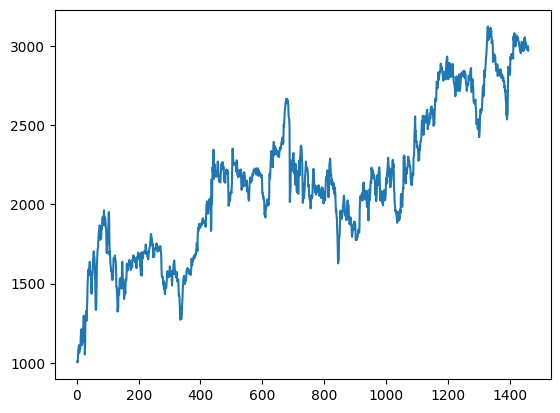

In [ ]:
df['net_equity'].plot()

## Exercises

1. Add transaction fees
2. Display equity curve factoring in fees
3. Add trade sizing starting with $12